In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification


print(f'Torch version: {torch.__version__}')
print(f'Cuda version: {torch.version.cuda}')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'💾 device: {device}')
if torch.cuda.is_available():
    print(f'Cuda Name: {torch.cuda.get_device_name(0)}')

Torch version: 2.10.0+cu130
Cuda version: 13.0
💾 device: cuda
Cuda Name: NVIDIA GeForce RTX 5080 Laptop GPU


In [2]:
import pandas as pd
from utils import glob_val, target_proc, ft

X_train = pd.read_csv(f'{glob_val.X_DATA_DIR}/x_train_str.csv')
y_train = pd.read_csv(f'{glob_val.TARGET_DIR}/y_train.csv')

X_test = pd.read_csv(f'{glob_val.X_DATA_DIR}/x_test_str.csv')
y_test = pd.read_csv(f'{glob_val.TARGET_DIR}/y_test.csv')

X_val = pd.read_csv(f'{glob_val.X_DATA_DIR}/x_val_str.csv')
y_val = pd.read_csv(f'{glob_val.TARGET_DIR}/y_val.csv')

print('Колонки таргет:')
print(f'   {y_train.columns}\n')

print('Train:')
print(f'* x: {X_train.shape}')
print(f'* y: {y_train.shape}')
print('Val:')
print(f'* x: {X_val.shape}')
print(f'* y: {y_val.shape}')
print('Test:')
print(f'* x: {X_test.shape}')
print(f'* y: {y_test.shape}')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
c:\Users\acer\miniconda3\envs\nlp\lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Структура папок проверена
Колонки таргет:
   Index(['category_1', 'category_2', 'category_3'], dtype='object')

Train:
* x: (304703, 1)
* y: (304703, 3)
Val:
* x: (43017, 1)
* y: (43017, 3)
Test:
* x: (10755, 1)
* y: (10755, 3)


In [3]:
y_test = y_test['category_1'].to_numpy()
y_val = y_val['category_1'].to_numpy()
y_train = y_train['category_1'].to_numpy()
index_in_class_dict, class_in_index_dict= target_proc.target_dict_load('category_1')
classes = list(class_in_index_dict.keys())

print(f'Classes: {classes}')
print(f'Example: {y_test[:10]}')

🟩 Словари таргетов загружены. Path:data/target/category_1.json
Classes: ['Сад', 'Водоснабжение', 'Инструменты', 'Сантехника', 'Скобяные изделия', 'Хранение', 'Декор', 'Стройматериалы', 'Краски', 'Электротовары', 'Кухни', 'Напольные покрытия', 'Освещение', 'Плитка', 'Окна и двери', 'Столярные изделия']
Example: [ 9  0  0  0  1 15  9  7  0  3]


In [4]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [6]:
train_dataset = TextDataset(X_train['name'].tolist(), y_train)
val_dataset = TextDataset(X_val['name'].tolist(), y_val)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [7]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(classes)
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [10]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

In [12]:
from tqdm import tqdm_notebook

for epoch in range(3):
    model.train()

    for batch in tqdm_notebook(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} loss:", loss.item())

C:\Users\acer\AppData\Local\Temp\ipykernel_2792\856160861.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch in tqdm_notebook(train_loader):


  0%|          | 0/38088 [00:00<?, ?it/s]

Epoch 0 loss: 0.18179096281528473


  0%|          | 0/38088 [00:00<?, ?it/s]

Epoch 1 loss: 0.09881026297807693


  0%|          | 0/38088 [00:00<?, ?it/s]

Epoch 2 loss: 0.006853930186480284


In [13]:
model.save_pretrained("models/bert_text_classifier")
tokenizer.save_pretrained("models/bert_text_classifier")

('models/bert_text_classifier\\tokenizer_config.json',
 'models/bert_text_classifier\\special_tokens_map.json',
 'models/bert_text_classifier\\vocab.txt',
 'models/bert_text_classifier\\added_tokens.json')

In [14]:
import numpy as np

def get_predictions(model, dataset, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size)
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())

    return np.array(preds)

In [15]:
test_dataset = TextDataset(X_test['name'].tolist(), y_test)

y_pred = get_predictions(model, test_dataset)
y_true = np.array(test_dataset.labels)

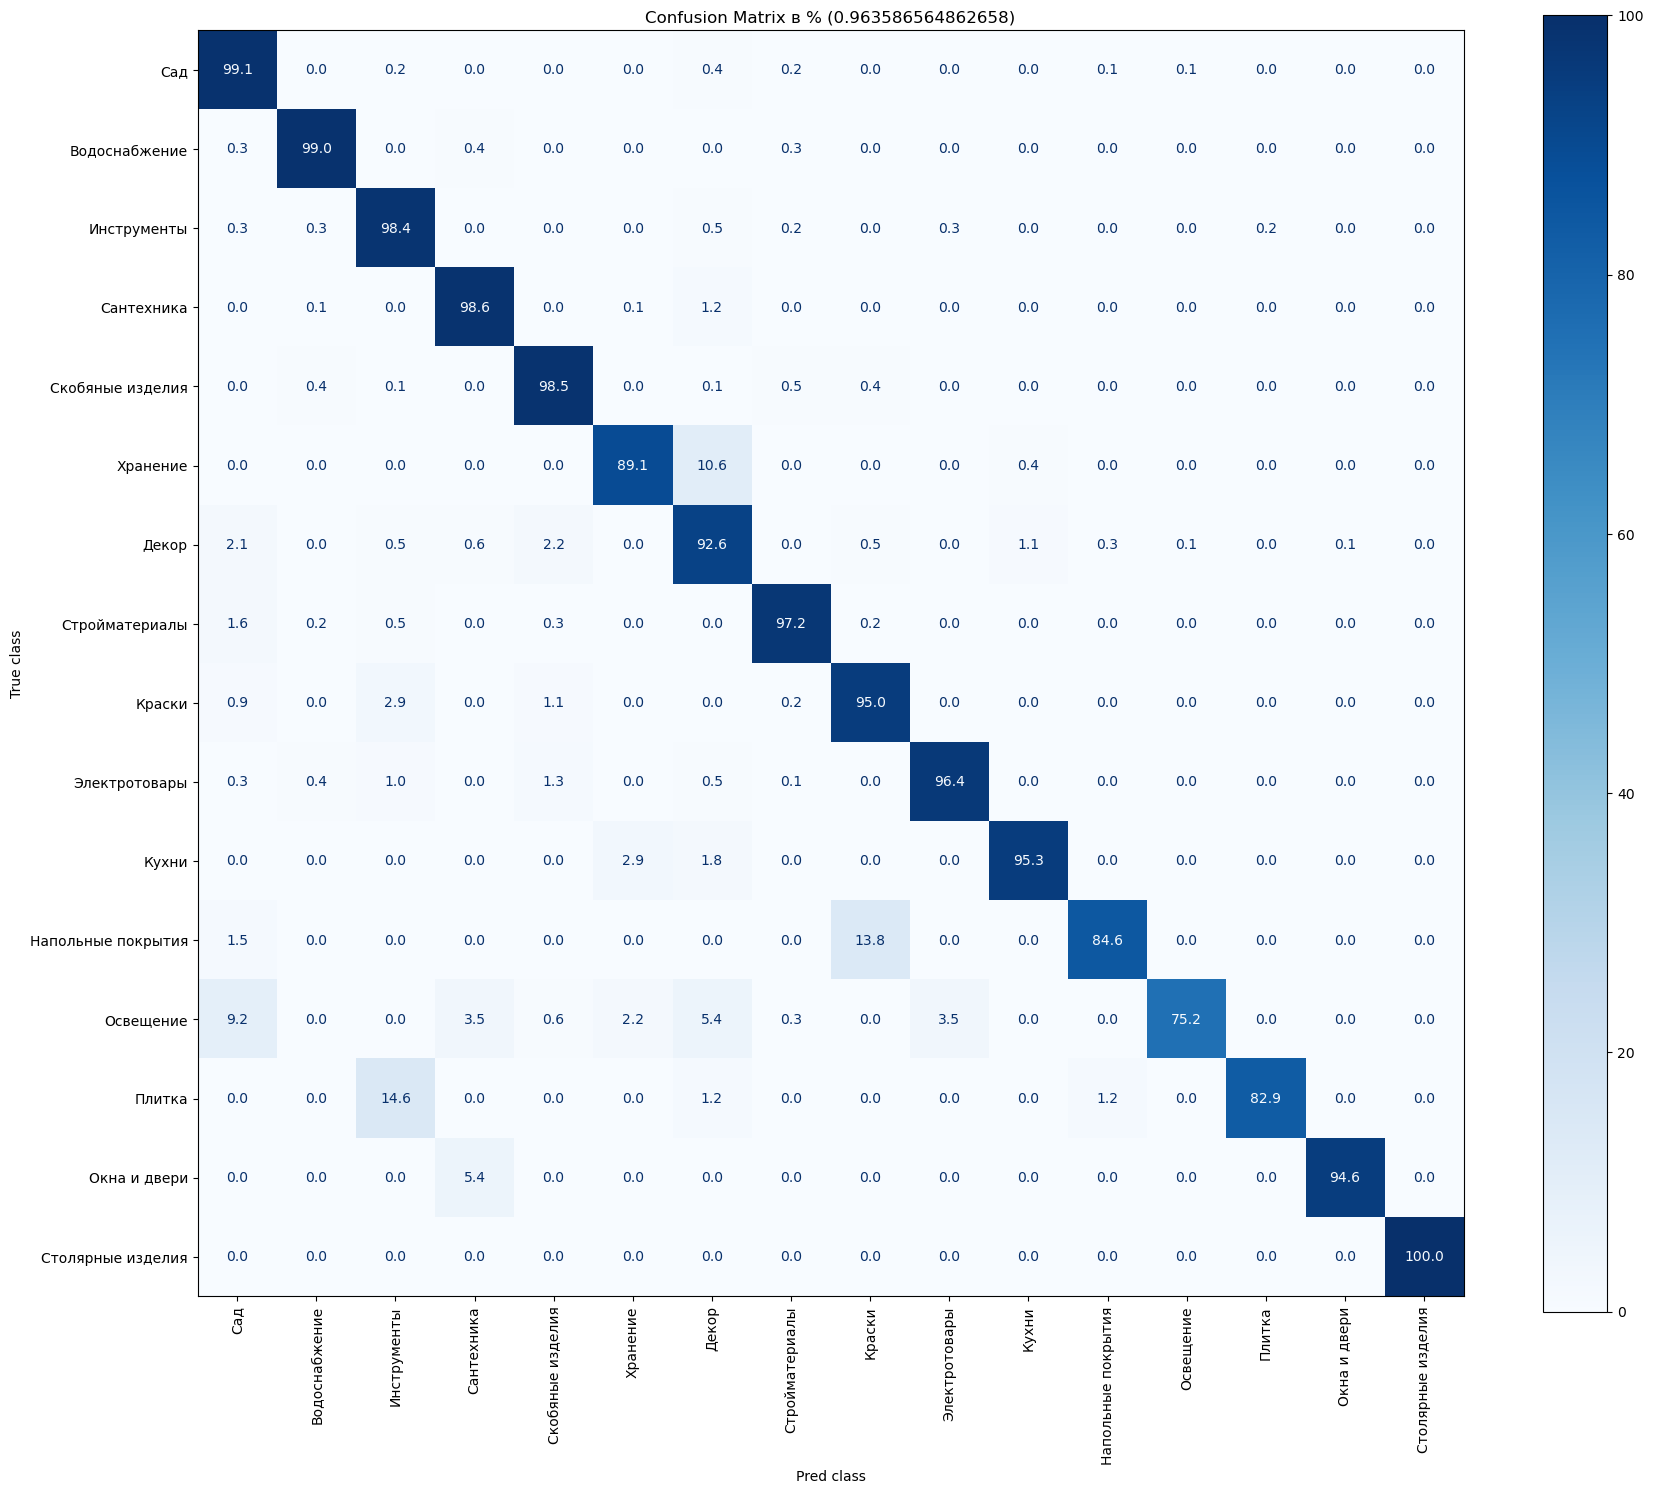

In [16]:
from utils.ft import cm_show

cm_show(
    y_true,
    y_pred,
    classes
)